In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
import pickle

with open("/content/drive/MyDrive/Genotek kinship recognition/Wikipedia dataset/files/Wikipedia_buffalo_sc_faces_info.pkl", "rb") as f:
  buffalo_sc_embeddings = pickle.load(f)

In [8]:
import json

with open("/content/drive/MyDrive/Genotek kinship recognition/Wikipedia dataset/files/picture_nums_to_urls.json", "r") as f:
  picture_nums_to_urls = json.load(f)

In [11]:
urls_to_picture_nums = {v: k for k, v in picture_nums_to_urls.items()}

In [3]:
import pandas as pd

In [12]:
train = pd.read_csv("/content/drive/MyDrive/Genotek kinship recognition/Wikipedia dataset/files/train_pairs.csv")
val = pd.read_csv("/content/drive/MyDrive/Genotek kinship recognition/Wikipedia dataset/files/val_pairs.csv")
test = pd.read_csv("/content/drive/MyDrive/Genotek kinship recognition/Wikipedia dataset/files/test_pairs.csv")
train.shape, val.shape, test.shape

((77746, 6), (6252, 6), (5758, 6))

In [10]:
train

,person1,person2,image1,image2,relationship,are_related
0,Q1484216,Q2570,http://commons.wikimedia.org/wiki/Special:File...,http://commons.wikimedia.org/wiki/Special:File...,parent - child,1
1,Q314834,Q2593,http://commons.wikimedia.org/wiki/Special:File...,http://commons.wikimedia.org/wiki/Special:File...,parent - child,1
2,Q3266318,Q2757,http://commons.wikimedia.org/wiki/Special:File...,http://commons.wikimedia.org/wiki/Special:File...,parent - child,1
3,Q3266318,Q2757,http://commons.wikimedia.org/wiki/Special:File...,http://commons.wikimedia.org/wiki/Special:File...,parent - child,1
4,Q3266318,Q2757,http://commons.wikimedia.org/wiki/Special:File...,http://commons.wikimedia.org/wiki/Special:File...,parent - child,1
...,...,...,...,...,...,...
77741,Q571190,Q260955,http://commons.wikimedia.org/wiki/Special:File...,http://commons.wikimedia.org/wiki/Special:File...,NaN,0
77742,Q3482430,Q1053620,http://commons.wikimedia.org/wiki/Special:File...,http://commons.wikimedia.org/wiki/Special:File...,NaN,0
77743,Q1480,Q16297911,http://commons.wikimedia.org/wiki/Special:File...,http://commons.wikimedia.org/wiki/Special:File...,NaN,0
77744,Q28755,Q601495,http://commons.wikimedia.org/wiki/Special:File...,http://commons.wikimedia.org/wiki/Special:File...,NaN,0


In [14]:
train["image1"][0]

'http://commons.wikimedia.org/wiki/Special:FilePath/John%20Romita%20Sr%2C%202006.jpg'

In [16]:
train["image1_num"] = train["image1"].apply(lambda x: urls_to_picture_nums[x[x.rfind("/")+1:]])
train["image2_num"] = train["image2"].apply(lambda x: urls_to_picture_nums[x[x.rfind("/")+1:]])
val["image1_num"] = val["image1"].apply(lambda x: urls_to_picture_nums[x[x.rfind("/")+1:]])
val["image2_num"] = val["image2"].apply(lambda x: urls_to_picture_nums[x[x.rfind("/")+1:]])
test["image1_num"] = test["image1"].apply(lambda x: urls_to_picture_nums[x[x.rfind("/")+1:]])
test["image2_num"] = test["image2"].apply(lambda x: urls_to_picture_nums[x[x.rfind("/")+1:]])

In [22]:
from scipy.spatial.distance import cosine

def get_distance(image1, image2, embeddings, prefix):
    image1 = prefix + image1
    image2 = prefix + image2
    if embeddings[image1] is None or embeddings[image2] is None:
        return None
    return cosine(embeddings[image1]["embedding"], embeddings[image2]["embedding"])


train["distance"] = train.apply(lambda x: get_distance(x["image1_num"], x["image2_num"], buffalo_sc_embeddings, ""), axis=1)
train_non_empty = train[train["distance"].notna()]
train_non_empty.shape

(75388, 9)

In [23]:
val["distance"] = val.apply(lambda x: get_distance(x["image1_num"], x["image2_num"], buffalo_sc_embeddings, ""), axis=1)
val_non_empty = val[val["distance"].notna()]
val_non_empty.shape

(6007, 9)

In [25]:
test["distance"] = test.apply(lambda x: get_distance(x["image1_num"], x["image2_num"], buffalo_sc_embeddings, ""), axis=1)
test_non_empty = test[test["distance"].notna()]
test_non_empty.shape

(5560, 9)

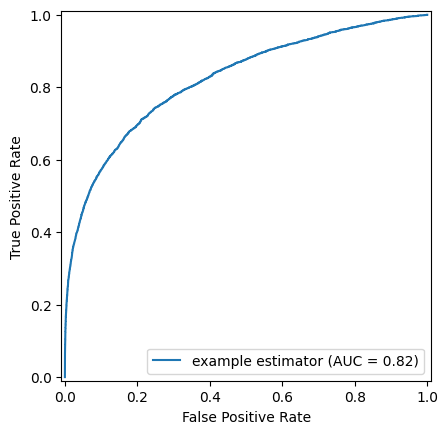

In [26]:
from sklearn import metrics



y = train_non_empty['are_related']
pred = -train_non_empty["distance"]


fpr, tpr, thresholds = metrics.roc_curve(y, pred)
roc_auc = metrics.auc(fpr, tpr)
display = metrics.RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc,
                                  estimator_name='example estimator')
display.plot()

In [28]:
from sklearn.metrics import roc_curve
import numpy as np


def get_matrix_values(y_score, y_true):
    ###
    # Compute the TPR and FPR for different thresholds
    ###
    fpr, tpr, thresholds = roc_curve(y_true, y_score)

    ###
    # Calculate the number of positive and negative samples
    ###
    P = np.sum(y_true == 1)
    N = np.sum(y_true == 0)

    ###
    # Compute TP, TN, FP, and FN for each threshold
    ###
    tps = tpr * P
    tns = (1 - fpr) * N
    fps = fpr * N
    fns = P - tps



    return tps, fps, tns, fns, thresholds #if score >= threshold, we assign the class 1


def get_accuracy_curve(y_score, y_true):
    tps, fps, tns, fns, thresholds = get_matrix_values(y_score, y_true)
    accuracy = (tps + tns) / (tps + tns + fns + fps)
    return accuracy, thresholds

In [31]:
y_score = np.array(train_non_empty["distance"])


accuracies, thresholds = get_accuracy_curve(-y_score, np.array(train_non_empty["are_related"]))

In [32]:
best_threshold = -max(zip(accuracies, thresholds), key = lambda x: x[0])[1]
best_acc = max(accuracies)
best_threshold, best_acc

(0.9454211098814481, 0.7496418528147716)

In [33]:
from sklearn.metrics import accuracy_score

preds = test_non_empty["distance"] < best_threshold
accuracy_score(test_non_empty["are_related"], preds)

0.7383093525179856